
--> The keys in the returned dictionary of datasets are constructed as follows:
	'date.cycle.forecast_hour.domain.variable.path'


/vftmp/Aparna.Radhakrishnan/pid2431286/ipykernel_2819895/2176079803.py:30: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Dataset key: {key} and dims {ds.dims['step']}")


Dataset key: 2025-07-02.0.1.ak.avrg./home/a1r/grib/rrfs_grib_data/refs.t00z.ak.avrg.f01.grib2 and dims 1
Dataset key: 2025-07-02.0.3.ak.avrg./home/a1r/grib/rrfs_grib_data/refs.t00z.ak.avrg.f03.grib2 and dims 1
Dataset key: 2025-07-02.0.2.ak.avrg./home/a1r/grib/rrfs_grib_data/refs.t00z.ak.avrg.f02.grib2 and dims 1
<xarray.Dataset> Size: 36MB
Dimensions:     (step: 1, y: 1105, x: 1649)
Coordinates:
    time        datetime64[ns] 8B ...
  * step        (step) timedelta64[ns] 8B 01:00:00
    surface     float64 8B ...
    latitude    (y, x) float64 15MB dask.array<chunksize=(1105, 1649), meta=np.ndarray>
    longitude   (y, x) float64 15MB dask.array<chunksize=(1105, 1649), meta=np.ndarray>
    valid_time  datetime64[ns] 8B ...
Dimensions without coordinates: y, x
Data variables:
    tp          (step, y, x) float32 7MB dask.array<chunksize=(1, 1105, 1649), meta=np.ndarray>
Attributes: (12/15)
    GRIB_edition:                    2
    GRIB_centre:                     kwbc
    GRIB_centreD

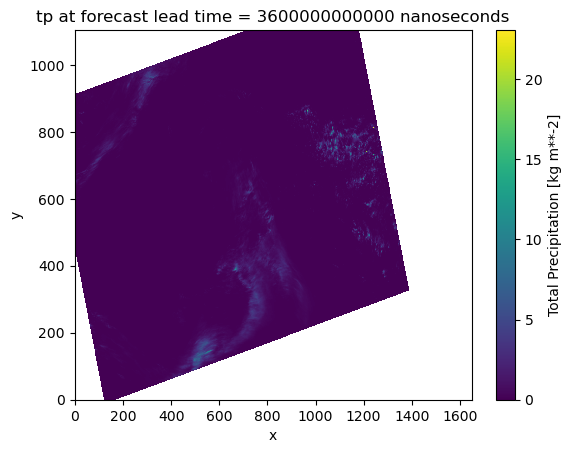

In [2]:
# %load test.py
import intake
import matplotlib.pyplot as plt

def preprocess(ds):
    if 'step' in ds.coords and 'step' not in ds.dims:
        ds = ds.expand_dims('step')
    return ds

cat = intake.open_esm_datastore('rrfs_ak_ensemble.json')
# Optionally filter catalog
subset = cat.search(domain='ak', variable='avrg')


dsets = subset.to_dataset_dict(
    xarray_open_kwargs={
        "engine": "cfgrib",
        "backend_kwargs": {
            "indexpath": ""},
    },
    preprocess=preprocess,
    aggregate=True
)

#print(list(dsets.key()))
#ds = list(dsets.values())[0]
#print(ds)

for key, ds in dsets.items():
    print(f"Dataset key: {key} and dims {ds.dims['step']}")
    #print(ds)


# Assuming you have `dsets` from intake-esm open_dataset_dict call
# Pick the first dataset (forecast hour 1, for example)
ds = list(dsets.values())[0]

print(ds)

print("Dimensions:", ds.dims)
print("Coordinates:", ds.coords)
# List variables available
print("Variables:", list(ds.data_vars))

# Pick a variable to plot, e.g., first variable
var = list(ds.data_vars)[0]
print(f"Plotting variable: {var}")

# 1. Plot a time series (mean over spatial dims) along forecast_hour
# (assuming forecast_hour is coordinate and spatial dims are lat/lon)
# Compute spatial mean over lat/lon dims (adjust to your actual dims)
spatial_dims = [dim for dim in ['x', 'y', 'lat', 'latitude', 'lon', 'longitude'] if dim in ds.dims]
#ts = ds[var].mean(dim=spatial_dims)
#ts.plot()
#plt.title(f"Spatial mean of {var} over forecast lead time")
#plt.xlabel("step")
#plt.ylabel(var)
#plt.grid(True)
#plt.show()

# 2. Plot a spatial map at a specific forecast_hour (e.g., first one)
ds[var].isel(step=0).plot()
plt.title(f"{var} at forecast lead time = {ds.step.values[0]}")
plt.show()


